In [1]:
import numpy as np  # for numerical operations and array handling
import pandas as pd  # for data manipulation and analysis using DataFrames
import matplotlib.pyplot as plt  # for creating visualizations and plots
import seaborn as sns  # for advanced and aesthetically pleasing data visualizations
import math
import matplotlib.pyplot as plt
import glob
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

In [2]:
df6 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S006.csv')
df8 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S008.csv')
df9 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S009.csv')
df10 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S010.csv')
df12 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S012.csv')
df13 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S013.csv')
df14 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S014.csv')
df15 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S015.csv')
df16 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S016.csv')
df17 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S017.csv')
df18 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S018.csv')
df19 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S019.csv')
df20 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S020.csv')
df21 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S021.csv')
df22 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S022.csv')
df23 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S023.csv')
df24 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S024.csv')
df25 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S025.csv')
df26 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S026.csv')
df27 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S027.csv')
df28 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S028.csv')
df29 = pd.read_csv(r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\S029.csv')


In [3]:
df_list = [df6, df8, df9, df10, df12, df13, df14, df15, df16, df17, df18, df19, df20, df21, df22, df23, df24, df25, df26, df27, df28, df29 ]

In [4]:
for df in df_list:
    print("the shape is ", df.shape)

the shape is  (408709, 8)
the shape is  (418989, 8)
the shape is  (154464, 8)
the shape is  (351649, 8)
the shape is  (382414, 8)
the shape is  (369077, 8)
the shape is  (366487, 8)
the shape is  (418392, 9)
the shape is  (355418, 8)
the shape is  (366609, 8)
the shape is  (322271, 8)
the shape is  (297945, 8)
the shape is  (371496, 8)
the shape is  (302247, 9)
the shape is  (337602, 8)
the shape is  (137646, 9)
the shape is  (170534, 8)
the shape is  (231729, 8)
the shape is  (195172, 8)
the shape is  (158584, 8)
the shape is  (165178, 8)
the shape is  (178716, 8)


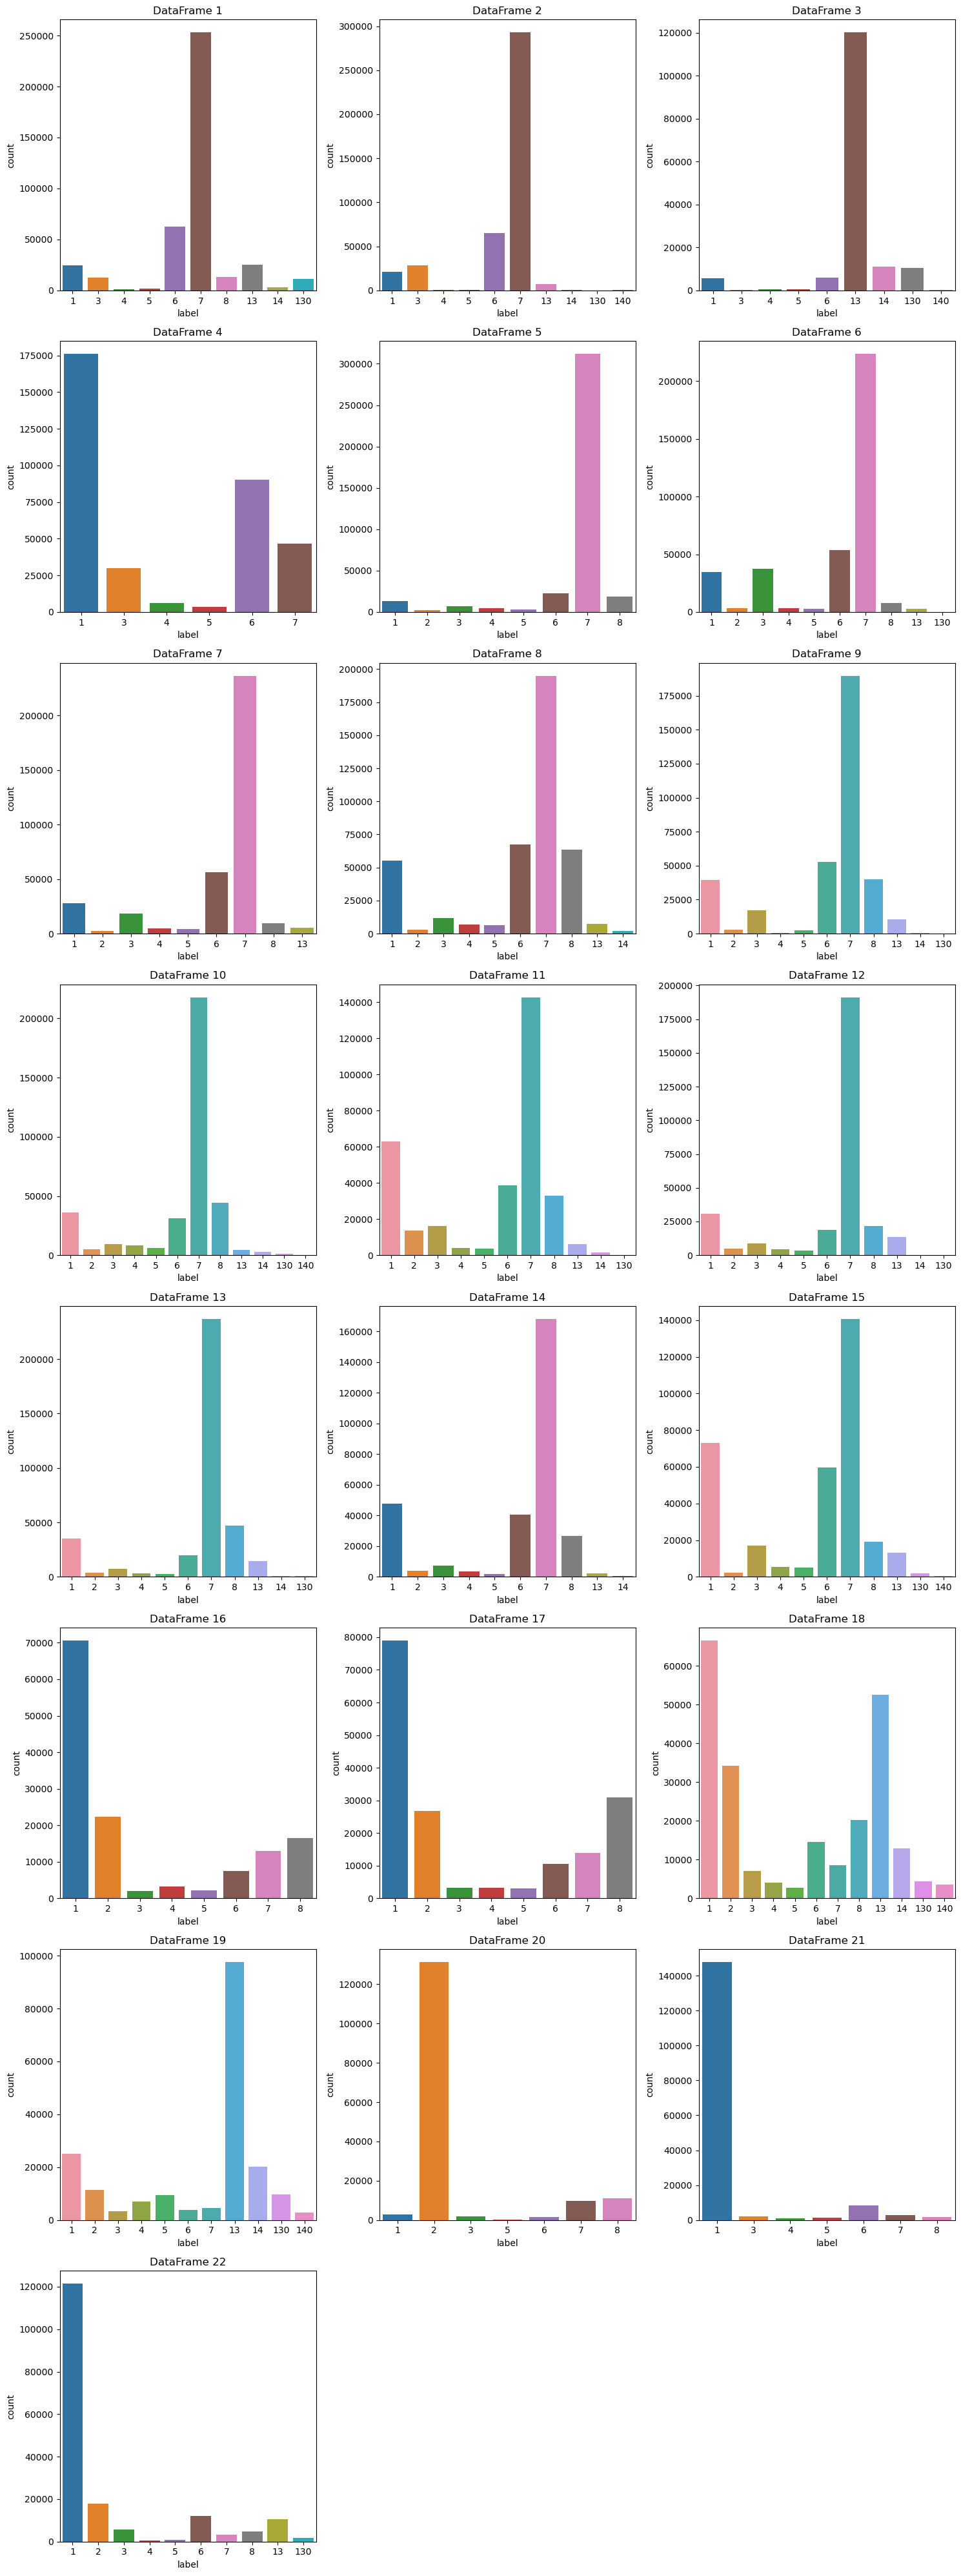

In [5]:
n_cols = 3
n_rows = math.ceil(len(df_list) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array for easier indexing
axes = axes.flatten()

for i, df in enumerate(df_list):
    sns.countplot(x='label', data=df, ax=axes[i])   # countplot is simpler than catplot
    axes[i].set_title(f"DataFrame {i+1}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
folder_path = r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth'

csv_files = glob.glob(os.path.join(folder_path, "S*.csv"))

dataframes = []
for f in csv_files:
    subject_id = os.path.basename(f).split('.')[0]
    df = pd.read_csv(f)
    df['subject'] = subject_id
    dataframes.append(df)

df_all = pd.concat(dataframes, ignore_index=True)

print("combined")


combined


In [7]:
df_all['label'].value_counts()

label
7      2902703
1      1197155
6       743480
8       428898
13      393963
2       291356
3       254839
4        76217
5        67253
14       55814
130      41785
140       7865
Name: count, dtype: int64

In [8]:
df_all.replace({'label':{13:0}}, inplace=True)
df_all.replace({'label':{14:9}}, inplace=True)

In [9]:
df_all['label'].value_counts()

label
7      2902703
1      1197155
6       743480
8       428898
0       393963
2       291356
3       254839
4        76217
5        67253
9        55814
130      41785
140       7865
Name: count, dtype: int64

In [10]:
# test_subject = 'S006'

# train_df = df_all[df_all['subject'] != test_subject]
# test_df  = df_all[df_all['subject'] == test_subject]

# print("Training samples:", len(train_df))
# print("Testing samples:", len(test_df))


In [11]:
df_all['label'].value_counts()

label
7      2902703
1      1197155
6       743480
8       428898
0       393963
2       291356
3       254839
4        76217
5        67253
9        55814
130      41785
140       7865
Name: count, dtype: int64

In [12]:
# CLASSES:
#   - { label: 1,  name: 'walking',                             }
#   - { label: 2,  name: 'running',                             }
#   - { label: 3,  name: 'shuffling',                           }
#   - { label: 4,  name: 'stairs (ascending)',                  }
#   - { label: 5,  name: 'stairs (descending)',                 }
#   - { label: 6,  name: 'standing',                            }
#   - { label: 7,  name: 'sitting',                             }
#   - { label: 8,  name: 'lying',                               }
#   - { label: 13, name: 'cycling (sit)',                       }
#   - { label: 14, name: 'cycling (stand)',                     }

In [13]:
df_all.drop(df_all[df_all['label'] == 130].index, inplace=True)
df_all.drop(df_all[df_all['label'] == 140].index, inplace=True)

In [14]:
df_all['label'].value_counts()

label
7    2902703
1    1197155
6     743480
8     428898
0     393963
2     291356
3     254839
4      76217
5      67253
9      55814
Name: count, dtype: int64

In [15]:
df_all['label'].value_counts()

label
7    2902703
1    1197155
6     743480
8     428898
0     393963
2     291356
3     254839
4      76217
5      67253
9      55814
Name: count, dtype: int64

In [16]:
df_all.shape

(6411678, 11)

In [17]:
df_all.head()

,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject,index,Unnamed: 0
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,S006,NaN,NaN
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,S006,NaN,NaN
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,S006,NaN,NaN
3,2019-01-12 00:00:00.030,-0.648772,0.016579,-0.054284,-1.554248,-0.950978,-0.221140,6,S006,NaN,NaN
4,2019-01-12 00:00:00.040,-0.355071,-0.051831,-0.113419,-0.547471,0.140903,-0.653782,6,S006,NaN,NaN


In [18]:
df_all.drop('Unnamed: 0', axis=1, inplace=True)
df_all.drop('index', axis=1, inplace=True)

In [19]:
df_all.shape

(6411678, 9)

In [20]:
df_all.head()

,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,S006
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,S006
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,S006
3,2019-01-12 00:00:00.030,-0.648772,0.016579,-0.054284,-1.554248,-0.950978,-0.221140,6,S006
4,2019-01-12 00:00:00.040,-0.355071,-0.051831,-0.113419,-0.547471,0.140903,-0.653782,6,S006


In [21]:
# test_subject = 'S006'

# train_df = df_all[df_all['subject'] != test_subject]
# test_df  = df_all[df_all['subject'] == test_subject]

# print("Training samples:", len(train_df))
# print("Testing samples:", len(test_df))


In [22]:
# feature_columns = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']
# target_column = 'label' 

# X_train = train_df[feature_columns]
# y_train = train_df[target_column]

# X_test = test_df[feature_columns]
# y_test = test_df[target_column]

In [23]:
# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)
# print("X_test shape:", X_test.shape)
# print("y_test shape:", y_test.shape)

In [24]:
TIME_STEPS = 50
N_FEATURES = 6
N_CLASSES = 10

def build_har_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [25]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

feature_columns = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']
target_column = 'label' 

subjects = df_all['subject'].unique()
n_classes = 10  # adjust if your dataset changes
TIME_STEPS = 50
N_FEATURES = 6

# --- Storage for global metrics ---
conf_matrix_sum = np.zeros((n_classes, n_classes), dtype=int)
precision_list, recall_list, f1_list = [], [], []

# --- Helper to segment time windows ---
def segment_data(X_data, y_data, time_steps):
    X = X_data.values 
    y = y_data.values

    if len(X) % time_steps != 0:
        trim_size = len(X) % time_steps
        X = X[:-trim_size]
        y = y[:-trim_size]
    
    num_windows = len(X) // time_steps
    X_reshaped = X.reshape(num_windows, time_steps, N_FEATURES)
    y_reshaped = y[time_steps - 1::time_steps] 
    return X_reshaped, y_reshaped

# --- Leave-One-Subject-Out loop ---
for test_subject in subjects:
    print(f"\n===== Testing on {test_subject} =====")

    train_df = df_all[df_all['subject'] != test_subject]
    test_df  = df_all[df_all['subject'] == test_subject]

    X_train = train_df[feature_columns]
    y_train = train_df[target_column]
    X_test  = test_df[feature_columns]
    y_test  = test_df[target_column]

    # --- Segment data into time windows ---
    X_train_seg, y_train_seg = segment_data(X_train, y_train, TIME_STEPS)
    X_test_seg, y_test_seg   = segment_data(X_test, y_test, TIME_STEPS)

    # --- Build and compile model ---
    model = build_har_model((TIME_STEPS, N_FEATURES), n_classes)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # --- Train ---
    model.fit(X_train_seg, y_train_seg, epochs=23, batch_size=32, verbose=0)

    # --- Evaluate ---
    y_pred = np.argmax(model.predict(X_test_seg), axis=1)

    # --- Confusion matrix and metrics ---
    cm = confusion_matrix(y_test_seg, y_pred, labels=range(n_classes))
    conf_matrix_sum += cm

    precision_list.append(precision_score(y_test_seg, y_pred, average='macro', zero_division=0))
    recall_list.append(recall_score(y_test_seg, y_pred, average='macro', zero_division=0))
    f1_list.append(f1_score(y_test_seg, y_pred, average='macro', zero_division=0))

# --- Final aggregated results ---
final_conf_matrix = conf_matrix_sum
final_precision = np.mean(precision_list)
final_recall = np.mean(recall_list)
final_f1 = np.mean(f1_list)

print("\n===== LOSO Cross-Validation Results =====")
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1-score:", final_f1)
print("Aggregated Confusion Matrix:\n", final_conf_matrix)



===== Testing on S006 =====


E:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Testing on S008 =====


E:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Testing on S009 =====


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Testing on S028 =====


E:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Testing on S029 =====


E:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== LOSO Cross-Validation Results =====
Precision: 0.6933303260965555
Recall: 0.6821908408693916
F1-score: 0.6671957738445781
Aggregated Confusion Matrix:
 [[ 6801   140    15    76    58   305    85   161     0   239]
 [   89 20771   137  1193   552   580   565    39     9    55]
 [    1    78  5689     7    21    22     3     0     0     5]
 [   59  1280    13  1763    42    46  1786    58     6    22]
 [   59   572    17    29   782    23    19     2     0    17]
 [   16   529    17    22    26   726     8     0     0     1]
 [   62   566     5   970    19    12 12911   250     2    40]
 [  256    53     0    32     6     1    46 57500   163     0]
 [    0     3     0     5     0     0     0    86  8480     0]
 [  214    78    13    17    57    25    45     1     0   666]]


In [26]:
X_test_reshaped, y_test_segmented = segment_data(X_test, y_test, TIME_STEPS)
model.evaluate(X_test_reshaped,y_test_segmented)

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.8600 - loss: 0.4807


[0.29704007506370544, 0.9164313673973083]

In [27]:
raw_predictions = model.predict(X_test_reshaped)
predicted_indices = np.argmax(raw_predictions, axis=1)

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step


In [28]:
predicted_indices = np.argmax(raw_predictions, axis=1)
confidence_scores = np.max(raw_predictions, axis=1)
print(f"Predicted Indices Shape: {predicted_indices.shape}") 

Predicted Indices Shape: (3542,)


In [29]:
filepath = r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\saved_model.keras'
model.save(filepath)

In [30]:
# keras_model_path = r'C:\Users\Mariem\Desktop\Learning_Journey\HAR\harth\saved_model.keras'
# model = tf.keras.models.load_model(keras_model_path)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\Mariem\AppData\Local\Temp\tmpf0yxqlvb\assets


INFO:tensorflow:Assets written to: C:\Users\Mariem\AppData\Local\Temp\tmpf0yxqlvb\assets


Saved artifact at 'C:\Users\Mariem\AppData\Local\Temp\tmpf0yxqlvb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='keras_tensor_168')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1832353827536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353838864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353826960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353840784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353837328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353837904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832400182864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832400186896: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()


INFO:tensorflow:Assets written to: C:\Users\Mariem\AppData\Local\Temp\tmpb6na7_md\assets


INFO:tensorflow:Assets written to: C:\Users\Mariem\AppData\Local\Temp\tmpb6na7_md\assets


Saved artifact at 'C:\Users\Mariem\AppData\Local\Temp\tmpb6na7_md'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='keras_tensor_168')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1832353827536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353838864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353826960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353840784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353837328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832353837904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832400182864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1832400186896: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [32]:
len(tflite_model)

58584

In [33]:
len(tflite_quant_model)

20848

In [34]:
with open("tflite_model.tflite", "wb") as f:
    f.write(tflite_model)

In [35]:
with open("tflite_quant_model.tflite", "wb") as f:
    f.write(tflite_quant_model)